# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [20]:
import pandas as pd

In [21]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')
df.shape

(41188, 21)

In [22]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [23]:
df.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [24]:
# No literal NaNs, but several categorical columns use "unknown" as a placeholder for missing data
unknown_counts = (df.select_dtypes('object') == 'unknown').sum()
unknown_counts[unknown_counts > 0].sort_values(ascending=False)

/var/folders/fs/1cnfhfbs6k1_m4pxsl4857h00000gn/T/ipykernel_79519/2429425755.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  unknown_counts = (df.select_dtypes('object') == 'unknown').sum()


default      8597
education    1731
housing       990
loan          990
job           330
marital        80
dtype: int64

In [25]:
# pdays uses 999 as a sentinel for "not previously contacted" rather than a real day count
df['pdays'].value_counts().head()

pdays
999    39673
3        439
6        412
4        118
9         64
Name: count, dtype: int64

**Findings:**

- There are no literal `NaN` values anywhere in the dataset (`df.isna().sum()` is all zeros).
- Several categorical columns instead encode missing values with the string `"unknown"`: `default` (8,597 rows — ~21%), `education` (1,731), `housing` (990), `loan` (990), `job` (330), and `marital` (80). These should be treated as missing during encoding/imputation rather than as a legitimate category, especially `default` given how prevalent it is.
- `pdays` uses the sentinel value `999` to mean "client was not previously contacted" (39,673 of 41,188 rows, ~96%). This isn't missing data, but it shouldn't be used as a continuous numeric feature as-is — it's more informative to derive a binary "previously contacted" flag from it.
- Every column's dtype already matches its content (`int64`/`float64` for numeric fields, `object` for categorical fields), so no dtype coercion is needed. The `object` columns will still need to be encoded (e.g., one-hot) before modeling.
- Per the dataset notes, `duration` should be dropped for a realistic predictive model since it's only known after a call is made and leaks the target.

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

The business goal is to find a model that can explain success of a contact, i.e. if the client subscribes the deposit. Such model should increase campaign efficiency by identifying the main characteristics that affect success, helping in a better management of the available resources (e.g. human effort, phone calls, time) and selection of a high quality and affordable set of potential buying customers.

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [27]:
from sklearn.preprocessing import LabelEncoder
# 1. Separate the Target variable
# 'y' is the target (yes/no). We convert it to binary (1/0)
label_encoder = LabelEncoder()
df['y'] = label_encoder.fit_transform(df['y'])

# 2. Identify Categorical and Numerical columns
# We separate them to apply different transformations if needed
cat_cols = df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(exclude=['object']).columns.drop('y')


/var/folders/fs/1cnfhfbs6k1_m4pxsl4857h00000gn/T/ipykernel_79519/1703828305.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


In [28]:
# 3. Encode Categorical Features
# We use get_dummies to create binary columns for each category (One-Hot Encoding)
# This prevents the model from assuming an ordinal relationship between categories
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# 4. Final Separation of Features (X) and Target (y)
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

In [29]:
# Display the results
print(f"Original shape: {df.shape}")
print(f"Encoded features shape: {X.shape}")
print("\nFirst 5 rows of processed features:")
print(X.head())

Original shape: (41188, 21)
Encoded features shape: (41188, 53)

First 5 rows of processed features:
   age  duration  campaign  pdays  previous  emp.var.rate  cons.price.idx  \
0   56       261         1    999         0           1.1          93.994   
1   57       149         1    999         0           1.1          93.994   
2   37       226         1    999         0           1.1          93.994   
3   40       151         1    999         0           1.1          93.994   
4   56       307         1    999         0           1.1          93.994   

   cons.conf.idx  euribor3m  nr.employed  ...  month_may  month_nov  \
0          -36.4      4.857       5191.0  ...       True      False   
1          -36.4      4.857       5191.0  ...       True      False   
2          -36.4      4.857       5191.0  ...       True      False   
3          -36.4      4.857       5191.0  ...       True      False   
4          -36.4      4.857       5191.0  ...       True      False   

   month_

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
# Split the data into training (80%) and testing (20%) sets
# random_state ensures the split is reproducible
# stratify=y ensures the class distribution is preserved across both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

In [32]:
print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

# Verify the distribution of the target variable
print("\nTarget distribution in Training set:\n", y_train.value_counts(normalize=True))
print("\nTarget distribution in Testing set:\n", y_test.value_counts(normalize=True))

Training set size: (32950, 53)
Testing set size: (8238, 53)

Target distribution in Training set:
 y
0    0.887344
1    0.112656
Name: proportion, dtype: float64

Target distribution in Testing set:
 y
0    0.887351
1    0.112649
Name: proportion, dtype: float64


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [33]:
# Calculate the percentage of the majority class
baseline_accuracy = y_train.value_counts(normalize=True).max()

print(f"The baseline accuracy is: {baseline_accuracy:.2%}")

The baseline accuracy is: 88.73%


### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Initialize the Logistic Regression model
# We increase max_iter to ensure the model converges on the encoded dataset
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# 2. Train the model using the training set
log_reg.fit(X_train, y_train)



/Users/ashwin.patel/code/learn/ai-ml/capstone-1/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

### Problem 9: Score the Model

What is the accuracy of your model?

In [35]:

# 3. Make predictions on the training and test set
y_train_pred = log_reg.predict(X_train)
y_pred = log_reg.predict(X_test)

# 4. Evaluate the performance
print("--- Logistic Regression Performance ---")
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred):.2%}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 5. Confusion Matrix to see False Positives vs False Negatives
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

--- Logistic Regression Performance ---
Training Accuracy: 90.95%
Test Accuracy: 91.47%

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.98      0.95      7310
           1       0.70      0.43      0.53       928

    accuracy                           0.91      8238
   macro avg       0.81      0.70      0.74      8238
weighted avg       0.90      0.91      0.91      8238


Confusion Matrix:
 [[7139  171]
 [ 532  396]]


### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
| knn   | 0.4s       |92.06%          |90.22%         |
| Decision Tree | 0.01s       |91.60% |91.85% |
| SVM | 17.0s       |90.30% |90.59% |


In [36]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, f1_score

# 1. Scale the data (Crucial for KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Initialize and train the KNN model
# We'll start with k=5, a common default
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# 3. Make predictions
y_train_pred_knn = knn.predict(X_train_scaled)
y_pred_knn = knn.predict(X_test_scaled)


#print results
print("--- knn Performance ---")
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred_knn):.2%}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_knn):.2%}")


--- knn Performance ---
Training Accuracy: 92.06%
Test Accuracy: 90.22%


In [37]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score

# 1. Initialize and train the Decision Tree
# We set max_depth to prevent overfitting, which is a common issue with Trees
dtree = DecisionTreeClassifier(max_depth=5, random_state=42)
dtree.fit(X_train, y_train)

# 2. Make predictions
y_train_pred_dt = dtree.predict(X_train)
y_pred_dt = dtree.predict(X_test)

#print results
print("--- Decision Tree Performance ---")
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred_dt):.2%}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_dt):.2%}")


--- Decision Tree Performance ---
Training Accuracy: 91.60%
Test Accuracy: 91.85%


In [38]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

# 1. Scale the data (Mandatory for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Initialize and train the SVM model
# We use a linear kernel to keep it comparable to Logistic Regression's linearity
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_scaled, y_train)

# 3. Make predictions
y_train_pred_svm = svm_model.predict(X_train_scaled)
y_pred_svm = svm_model.predict(X_test_scaled)

#print results
print("--- SVM (kernel=linear) Performance ---")
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred_svm):.2%}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_svm):.2%}")



--- SVM (kernel=linear) Performance ---
Training Accuracy: 90.30%
Test Accuracy: 90.59%


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

#### Hyperparameter Tuning and Grid Search

Each model has hyperparameters that control its complexity and bias/variance trade-off (e.g. `C` in Logistic Regression and SVM, `n_neighbors` in KNN, `max_depth` in the Decision Tree). Below we use `GridSearchCV` with cross-validation to search over a range of values for each model and select the configuration that generalizes best.

Because the target is imbalanced (~89% "no" vs. ~11% "yes", see Problem 7), we score the grid search on **F1-score** rather than accuracy — a model that simply predicts the majority class would score ~89% accuracy while never identifying a single subscriber, which is not useful for the business objective from Problem 4.

In [39]:
from sklearn.model_selection import GridSearchCV
import time

# The target is imbalanced (~89% "no" / ~11% "yes"), so we score the grid
# search on F1 rather than accuracy - a model that always predicts "no"
# would score ~89% accuracy without ever finding a subscriber.
scoring_metric = 'f1'

# --- Logistic Regression ---
log_reg_params = {'C': [0.01, 0.1, 1, 10, 100]}

start = time.time()
log_reg_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    log_reg_params,
    scoring=scoring_metric,
    cv=5,
    n_jobs=-1
)
log_reg_grid.fit(X_train, y_train)
log_reg_time = time.time() - start
log_reg_best = log_reg_grid.best_estimator_

print(f"Best Logistic Regression params: {log_reg_grid.best_params_}")
print(f"Best CV {scoring_metric}-score: {log_reg_grid.best_score_:.4f}")
print(f"Grid search time: {log_reg_time:.1f}s")

/Users/ashwin.patel/code/learn/ai-ml/capstone-1/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/ashwin.patel/code/learn/ai-ml/capstone-1/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as sho

Best Logistic Regression params: {'C': 10}
Best CV f1-score: 0.5044
Grid search time: 7.5s


/Users/ashwin.patel/code/learn/ai-ml/capstone-1/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [40]:
# --- K-Nearest Neighbors ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights': ['uniform', 'distance']
}

start = time.time()
knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_params,
    scoring=scoring_metric,
    cv=3,
    n_jobs=-1
)
knn_grid.fit(X_train_scaled, y_train)
knn_time = time.time() - start
knn_best = knn_grid.best_estimator_

print(f"Best KNN params: {knn_grid.best_params_}")
print(f"Best CV {scoring_metric}-score: {knn_grid.best_score_:.4f}")
print(f"Grid search time: {knn_time:.1f}s")

Best KNN params: {'n_neighbors': 5, 'weights': 'distance'}
Best CV f1-score: 0.3958
Grid search time: 3.1s


In [41]:
# --- Decision Tree ---
dtree_params = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'criterion': ['gini', 'entropy']
}

start = time.time()
dtree_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dtree_params,
    scoring=scoring_metric,
    cv=5,
    n_jobs=-1
)
dtree_grid.fit(X_train, y_train)
dtree_time = time.time() - start
dtree_best = dtree_grid.best_estimator_

print(f"Best Decision Tree params: {dtree_grid.best_params_}")
print(f"Best CV {scoring_metric}-score: {dtree_grid.best_score_:.4f}")
print(f"Grid search time: {dtree_time:.1f}s")

Best Decision Tree params: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV f1-score: 0.5859
Grid search time: 4.4s


In [42]:
# --- Support Vector Machine ---
# SVM training time scales poorly with dataset size, so a full grid search
# on all ~33k training rows is impractical. We tune on a stratified
# 5,000-row sample, then refit the winning configuration on the full
# training set.
X_train_svm_sample, _, y_train_svm_sample, _ = train_test_split(
    X_train_scaled, y_train,
    train_size=5000,
    random_state=42,
    stratify=y_train
)

svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale']
}

start = time.time()
svm_grid = GridSearchCV(
    SVC(random_state=42),
    svm_params,
    scoring=scoring_metric,
    cv=3,
    n_jobs=-1
)
svm_grid.fit(X_train_svm_sample, y_train_svm_sample)
svm_search_time = time.time() - start

print(f"Best SVM params (found on a 5,000-row sample): {svm_grid.best_params_}")
print(f"Best CV {scoring_metric}-score: {svm_grid.best_score_:.4f}")
print(f"Grid search time: {svm_search_time:.1f}s")

# Refit the winning configuration on the full training set
start = time.time()
svm_best = SVC(random_state=42, **svm_grid.best_params_)
svm_best.fit(X_train_scaled, y_train)
svm_time = time.time() - start
print(f"Final SVM fit time (full training set): {svm_time:.1f}s")

Best SVM params (found on a 5,000-row sample): {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV f1-score: 0.4440
Grid search time: 1.3s
Final SVM fit time (full training set): 11.0s


#### Comparing the Tuned Models

With each model's best hyperparameters selected via cross-validated F1-score, we now evaluate all four tuned models on the held-out test set, alongside their fit times for reference.

In [43]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

tuned_models = {
    'Logistic Regression': (log_reg_best, X_test, log_reg_time),
    'KNN': (knn_best, X_test_scaled, knn_time),
    'Decision Tree': (dtree_best, X_test, dtree_time),
    'SVM': (svm_best, X_test_scaled, svm_time),
}

results = []
for name, (model, X_te, fit_time) in tuned_models.items():
    y_pred = model.predict(X_te)
    y_score = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else model.decision_function(X_te)

    results.append({
        'Model': name,
        'Fit Time (s)': round(fit_time, 2),
        'Test Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_score),
    })

tuned_results_df = pd.DataFrame(results).set_index('Model')
tuned_results_df

,Fit Time (s),Test Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,,
Logistic Regression,7.47,0.913571,0.698529,0.409483,0.516304,0.939815
KNN,3.10,0.900704,0.601103,0.352371,0.444293,0.834486
Decision Tree,4.35,0.912964,0.615553,0.605603,0.610538,0.908564
SVM,11.03,0.902525,0.587413,0.452586,0.511260,0.925854


#### Adjusting the Performance Metric

Accuracy is misleading here: because ~89% of clients do not subscribe, a trivial classifier that always predicts "no" already achieves ~89% accuracy (our baseline from Problem 7) without ever identifying a single successful contact.

Since the business objective (Problem 4) is to identify clients who are likely to subscribe — so the bank can focus its calling effort — we care most about:

- **Recall** (of the "yes" class): what fraction of actual subscribers we successfully identify.
- **Precision** (of the "yes" class): of the clients we predict will subscribe, how many actually do — this controls how much of the calling effort is wasted on false leads.
- **F1-score**: the harmonic mean of precision and recall; used above as the grid search's optimization target.
- **ROC-AUC**: measures ranking quality independent of a specific decision threshold, useful for comparing models overall.

The table and ROC curves below re-score each *tuned* model using these metrics instead of raw accuracy.

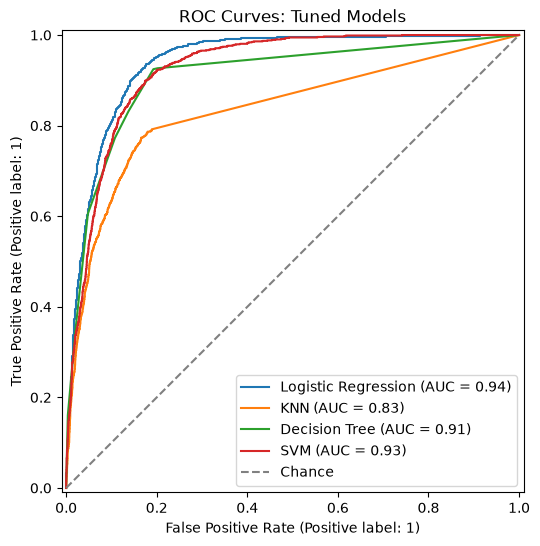

In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(7, 6))
for name, (model, X_te, _) in tuned_models.items():
    y_score = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else model.decision_function(X_te)
    RocCurveDisplay.from_predictions(y_test, y_score, name=name, ax=ax)

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
ax.set_title('ROC Curves: Tuned Models')
ax.legend()
plt.show()

**How to read these results:** Compare models using `tuned_results_df` and the ROC curves above rather than accuracy alone. The model with the strongest recall/F1/ROC-AUC on the "yes" class best serves the business objective of identifying likely subscribers (Problem 4), even if its raw test accuracy is similar to — or slightly lower than — another model's.

##### Questions